# SUNVEx and WRF-CHEM

This example demonstrates the basics available in MELODIES MONET to 
compare WRF-Chem results against one mobile drive in a field campaign.

This example evaluates WRF-Chem against the SUNVEx dataset:
https://csl.noaa.gov/projects/sunvex/

The observational data can be downloaded here: https://csl.noaa.gov/groups/csl7/measurements/mobilelab/MobileLabSUNVEx/DataDownload/

First, we import the {mod}`melodies_monet.driver` module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, {class}`melodies_monet.driver.analysis`.
It consists of these main parts:
* model instances
* observation instances
* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our {class}`~melodies_monet.driver.analysis` object's attributes
are set to ``None``, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

```{note}
Check out the {doc}`/appendix/yaml` for info on how to create
and modify these files.
```

In [4]:
an.control = "../yaml/control_wrfchem_mobile.yaml"
an.read_control()
an.control_dict

{'analysis': {'start_time': '2021-08-03-00:00:00',
  'end_time': '2021-08-04-05:00:00',
  'output_dir': './output/sunvex_mobile',
  'debug': True},
 'model': {'wrfchem_v4.2': {'files': '/wrk/d2/rschwantes/MM_example_data/sunvex_base_mobile/wrfout_d01_2021-08-0[3,4]_*',
   'mod_type': 'wrfchem',
   'mod_kwargs': {'mech': 'racm_esrl_vcp'},
   'mapping': {'sunvex_mobile': {'uvmet10_wspd': 'WindSpd_calc_m_s',
     'T2': 'AirTemp_C'}},
   'plot_kwargs': {'color': 'dodgerblue', 'marker': '^', 'linestyle': ':'}}},
 'obs': {'sunvex_mobile': {'filename': '/wrk/d2/rschwantes/MM_example_data/obs/sunvex/recap-NOAAMET_CSLML_20210803_R0.ict',
   'obs_type': 'mobile',
   'resample': '30s',
   'variables': {'WindSpd_calc_m_s': {'unit_scale': 1,
     'unit_scale_method': '*',
     'nan_value': -7777,
     'LLOD_value': -8888,
     'LLOD_setvalue': 0.0,
     'ylabel_plot': 'Wind Speed (m/s)'},
    'AirTemp_C': {'unit_scale': 273.15,
     'unit_scale_method': '+',
     'nan_value': -7777,
     'LLOD_valu

````{admonition} Note: This is the complete file that was loaded.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
```
````

Now, some of our {class}`~melodies_monet.driver.analysis` object's attributes are populated:

In [5]:
an

analysis(
    control='../yaml/control_wrfchem_mobile.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2021-08-03 00:00:00'),
    end_time=Timestamp('2021-08-04 05:00:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/sunvex_mobile',
    output_dir_save='./output/sunvex_mobile',
    output_dir_read='./output/sunvex_mobile',
    debug=True,
    save=None,
    read=None,
    regrid=False,
)

## Load the model data

The driver will automatically loop through the "models" found in the `model` section
of the YAML file and create an instance of {class}`melodies_monet.driver.model` for each
that includes the
* label
* mapping information
* file names (can be expressed using a glob expression)
* xarray object

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 24-56
```
````

In [6]:
an.open_models()

wrfchem
/wrk/d2/rschwantes/MM_example_data/sunvex_base_mobile/wrfout_d01_2021-08-0[3,4]_*
**** Reading WRF-Chem model output...


/home/rschwantes/miniconda3/envs/melodies-monet-pandas2/lib/python3.11/site-packages/monetio/models/_wrfchem_mm.py:149: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  dset = xr.merge(var_wrf_list)
/home/rschwantes/miniconda3/envs/melodies-monet-pandas2/lib/python3.11/site-packages/monetio/models/_wrfchem_mm.py:149: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or

Applying {meth}`~melodies_monet.driver.analysis.open_models`
populates the {attr}`~melodies_monet.driver.analysis.models` attribute.

In [7]:
an.models

{'wrfchem_v4.2': model(
     model='wrfchem',
     is_global=False,
     radius_of_influence=1000000.0,
     mod_kwargs={'mech': 'racm_esrl_vcp', 'var_list': ['T2', 'uvmet10_wspd_wdir', 'pres', 'height', 'tk', 'height_agl', 'PSFC', 'zstag']},
     file_str='/wrk/d2/rschwantes/MM_example_data/sunvex_base_mobile/wrfout_d01_2021-08-0[3,4]_*',
     label='wrfchem_v4.2',
     obj=...,
     extra_calc=None,
     mapping={'sunvex_mobile': {'uvmet10_wspd': 'WindSpd_calc_m_s', 'T2': 'AirTemp_C'}},
     variable_dict=None,
     label='wrfchem_v4.2',
     ...
 )}

We can access the underlying dataset with the
{attr}`~melodies_monet.driver.model.obj` attribute.

In [8]:
an.models['wrfchem_v4.2'].obj

<xarray.Dataset> Size: 3GB
Dimensions:        (y: 324, x: 264, time: 30, z: 50, bottom_top_stag: 51)
Coordinates:
    longitude      (y, x) float32 342kB -121.8 -121.7 -121.7 ... -113.5 -113.4
    latitude       (y, x) float32 342kB 30.29 30.3 30.3 ... 43.77 43.78 43.79
  * time           (time) datetime64[ns] 240B 2021-08-03 ... 2021-08-04T05:00:00
Dimensions without coordinates: y, x, z, bottom_top_stag
Data variables:
    T2             (time, y, x) float32 10MB 292.4 292.4 292.4 ... 290.8 291.7
    uvmet10_wspd   (time, y, x) float32 10MB 6.43 6.57 6.612 ... 1.87 2.348 3.18
    uvmet10_wdir   (time, y, x) float32 10MB 340.2 340.0 339.6 ... 233.2 230.3
    pres_pa_mid    (time, z, y, x) float32 513MB 1.017e+05 ... 5.584e+03
    alt_msl_m_mid  (time, z, y, x) float32 513MB 11.2 11.2 ... 2.034e+04
    temperature_k  (time, z, y, x) float32 513MB 292.2 292.2 ... 212.4 212.4
    alt_agl_m_mid  (time, z, y, x) float32 513MB 11.18 11.18 ... 1.856e+04
    surfpres_pa    (time, y, x) float32 10MB 1.018e+05 1.018e+05 ... 8.275e+04
    zstag          (time, bottom_top_stag, y, x) float32 523MB 0.01339 ... 2....
    dz_m           (time, z, y, x) float32 513MB 22.37 22.37 ... 1.305e+03
Attributes: (12/15)
    FieldType:                 104
    MemoryOrder:               XY 
    description:               TEMP at 2 M
    units:                     K
    stagger:                   
    coordinates:               XLONG XLAT XTIME
    ...                        ...
    MOAD_CEN_LAT:              37.097275
    STAND_LON:                 -97.0
    MAP_PROJ:                  1
    CEN_LAT:                   37.09727
    CEN_LON:                   -117.99237
    mapping_tables_to_airnow:  {'OZONE': 'o3', 'PM2.5': 'PM2_5_DRY', 'PM10': ...

## Load the observational data

As with the model data, the driver will loop through the "observations" found in
the `obs` section of the YAML file and create an instance of
{class}`melodies_monet.driver.observation` for each.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 58-99
```
````

In [9]:
an.open_obs()

In [10]:
an.obs

{'sunvex_mobile': observation(
     obs='sunvex_mobile',
     label='sunvex_mobile',
     file='/wrk/d2/rschwantes/MM_example_data/obs/sunvex/recap-NOAAMET_CSLML_20210803_R0.ict',
     obj=...,
     extra_calc=None,
     type='pt_src',
     sat_type=None,
     sat_method=None,
     data_proc=None,
     variable_dict={'WindSpd_calc_m_s': {'unit_scale': 1, 'unit_scale_method': '*', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'Wind Speed (m/s)'}, 'AirTemp_C': {'unit_scale': 273.15, 'unit_scale_method': '+', 'nan_value': -7777, 'LLOD_value': -8888, 'LLOD_setvalue': 0.0, 'ylabel_plot': 'T2 (K)'}, 'latitude': {'rename': 'latitude', 'unit_scale': 1, 'unit_scale_method': '*'}, 'longitude': {'rename': 'longitude', 'unit_scale': 1, 'unit_scale_method': '*'}},
     resample='30s',
     time_var=None,
     regrid_method=None,
 )}

In [11]:
an.obs['sunvex_mobile'].obj

<xarray.Dataset> Size: 89kB
Dimensions:            (time: 583)
Coordinates:
  * time               (time) datetime64[ns] 5kB 2021-08-03T21:27:00 ... 2021...
Data variables: (12/18)
    Timewave_UTC       (time) float64 5kB 7.723e+04 7.726e+04 ... 9.468e+04
    latitude           (time) float64 5kB 34.14 34.14 34.14 ... 34.14 34.14
    longitude          (time) float64 5kB -118.1 -118.1 -118.1 ... -118.1 -118.1
    GPSAlt_m           (time) float64 5kB 235.0 234.9 235.1 ... 235.2 235.4
    AirTemp_C          (time) float64 5kB 313.1 313.1 313.0 ... 300.5 300.4
    RelHumidity_pct    (time) float64 5kB 19.68 19.71 19.53 ... 29.93 29.98 29.9
    ...                 ...
    WindDir_rel_deg    (time) float64 5kB 132.4 83.04 206.9 ... 268.2 180.1
    WindSpd_calc_m_s   (time) float64 5kB 0.611 1.046 0.989 ... 0.5137 0.18
    WindDir_calc_deg   (time) float64 5kB 187.4 274.4 243.1 ... 151.5 277.3
    Sonic_WindSpd_m_s  (time) float64 5kB 0.6677 1.102 1.041 ... 0.5957 0.2
    Sonic_WindDir_deg  (time) float64 5kB 181.3 72.67 88.14 ... 175.3 284.9 62.5
    Pressure_mb        (time) float64 5kB 991.5 991.4 991.3 ... 989.8 989.8
Attributes: (12/22)
    source:               Airmar Wx and Differential GPS
    Date Revised:         2021-08-10 00:00:00
    mission:              CSLMobileLab
    organization:         NOAA Chemical Sciences Laboratory
    PI:                   Ken Aikin, Jeff Peischl, Andy Neuman
    PI_CONTACT_INFO:      Address
    ...                   ...
    DM_CONTACT_INFO:      Data Manager
    PROJECT_INFO:         SUNVEx/RECAP dates of study
    STIPULATIONS_ON_USE:  Use of these data require prior ok from PI.
    OTHER_COMMENTS:       WindSpd_calc_m_s and WindDir_calc_deg calculated fr...
    REVISION:             R0
    R0:                   Final Data

## Pair model and observational data

Now, we create a {class}`melodies_monet.driver.pair` for each model--obs pair
using the {meth}`~melodies_monet.driver.analysis.pair_data` routine.

In [12]:
%%time

an.pair_data()

1, in pair data
After pairing:       Timewave_UTC   latitude                time   longitude    GPSAlt_m  \
0         77234.5  34.140280 2021-08-03 21:27:00 -118.125400  235.048276   
1         77264.5  34.140274 2021-08-03 21:27:30 -118.125405  234.933333   
2         77294.5  34.140260 2021-08-03 21:28:00 -118.125430  235.123333   
3         77324.5  34.140230 2021-08-03 21:28:30 -118.125460  235.382759   
4         77354.5  34.140145 2021-08-03 21:29:00 -118.125468  235.030000   
..            ...        ...                 ...         ...         ...   
572       94574.5  34.140156 2021-08-04 02:16:00 -118.125479  240.223333   
573       94604.5  34.140231 2021-08-04 02:16:30 -118.125479  236.763333   
574       94634.5  34.140244 2021-08-04 02:17:00 -118.125440  236.013333   
575       94664.5  34.140260 2021-08-04 02:17:30 -118.125390  235.196667   
576       94680.0  34.140270 2021-08-04 02:18:00 -118.125380  235.400000   

      AirTemp_C  RelHumidity_pct  Heading_deg  Course_d

In [13]:
an.paired

{'sunvex_mobile_wrfchem_v4.2': pair(
     type='mobile',
     radius_of_influence=None,
     obs='sunvex_mobile',
     model='wrfchem_v4.2',
     model_vars=['uvmet10_wspd', 'T2'],
     obs_vars=['WindSpd_calc_m_s', 'AirTemp_C'],
     filename='sunvex_mobile_wrfchem_v4.2.nc',
 )}

In [14]:
an.paired['sunvex_mobile_wrfchem_v4.2'].obj

<xarray.Dataset> Size: 92kB
Dimensions:            (x: 1, time: 577)
Coordinates:
  * time               (time) datetime64[ns] 5kB 2021-08-03T21:27:00 ... 2021...
Dimensions without coordinates: x
Data variables: (12/20)
    Timewave_UTC       (time, x) float64 5kB 7.723e+04 7.726e+04 ... 9.468e+04
    latitude           (time, x) float64 5kB 34.14 34.14 34.14 ... 34.14 34.14
    longitude          (time, x) float64 5kB -118.1 -118.1 ... -118.1 -118.1
    GPSAlt_m           (time, x) float64 5kB 235.0 234.9 235.1 ... 235.2 235.4
    AirTemp_C          (time, x) float64 5kB 313.1 313.1 313.0 ... 300.5 300.4
    RelHumidity_pct    (time, x) float64 5kB 19.68 19.71 19.53 ... 29.98 29.9
    ...                 ...
    WindDir_calc_deg   (time, x) float64 5kB 187.4 274.4 243.1 ... 151.5 277.3
    Sonic_WindSpd_m_s  (time, x) float64 5kB 0.6677 1.102 1.041 ... 0.5957 0.2
    Sonic_WindDir_deg  (time, x) float64 5kB 181.3 72.67 88.14 ... 284.9 62.5
    Pressure_mb        (time, x) float64 5kB 991.5 991.4 991.3 ... 989.8 989.8
    uvmet10_wspd       (time, x) float32 2kB 4.194 4.196 4.199 ... 1.908 1.905
    T2                 (time, x) float32 2kB 310.3 310.3 310.3 ... 302.9 302.9

## Plot

The {meth}`~melodies_monet.driver.analysis.plotting` routine produces plots.

````{admonition} Note: Relevant control file section.
:class: dropdown

```{literalinclude} control_wrfchem_mech-0905_2.yaml
:caption:
:linenos:
:lines: 101-240
```
````

Reference std: 1.3625307140975706
Reference std: 2.1936307892995806
CPU times: user 3.5 s, sys: 306 ms, total: 3.8 s
Wall time: 3.91 s


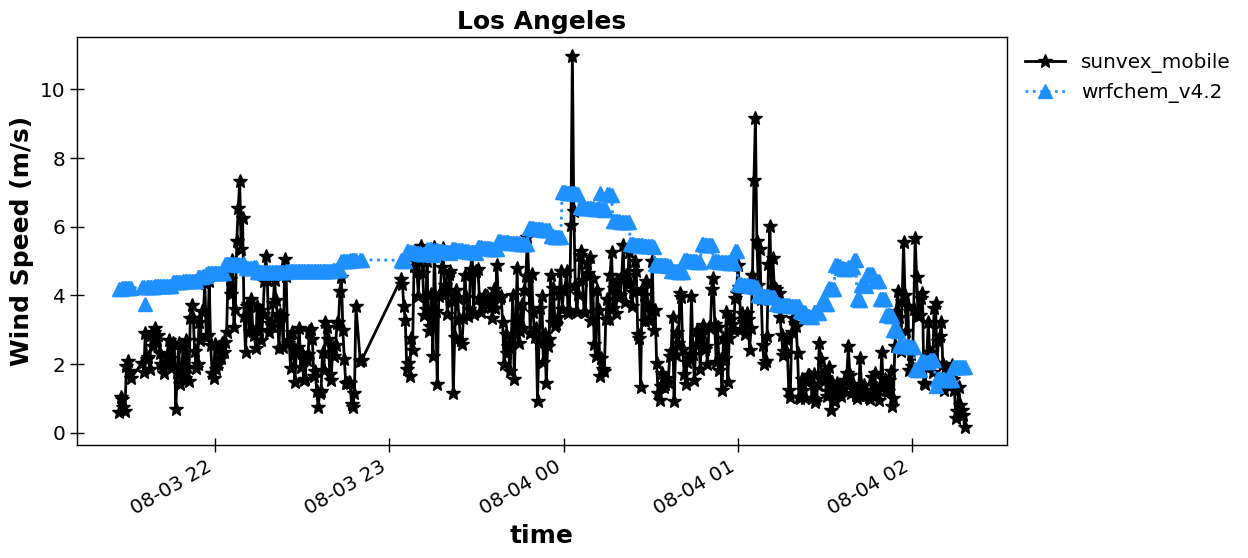

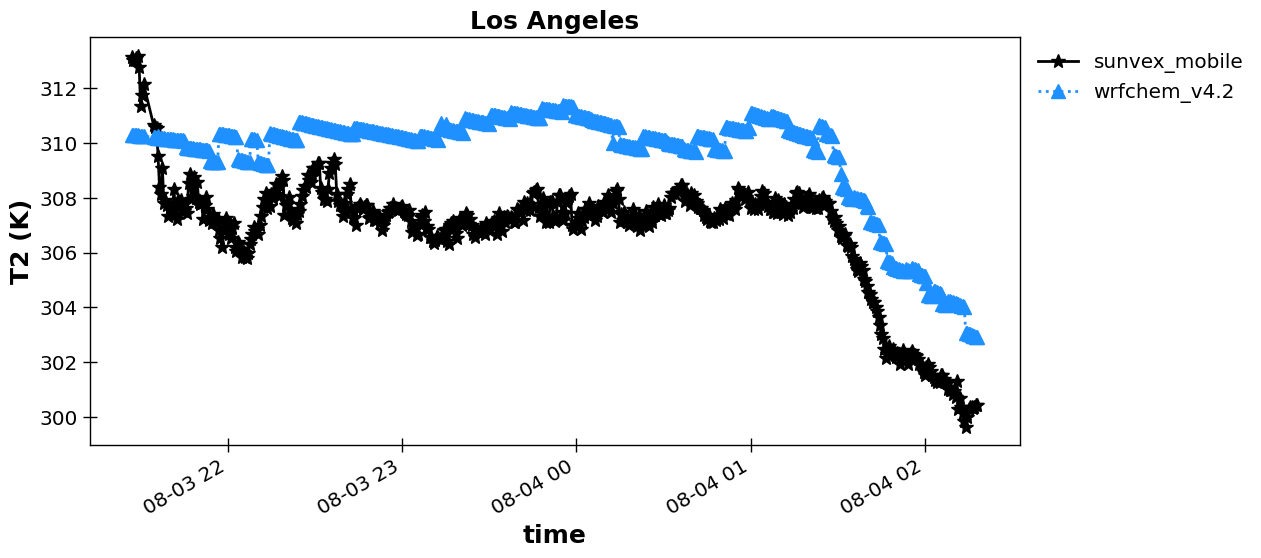

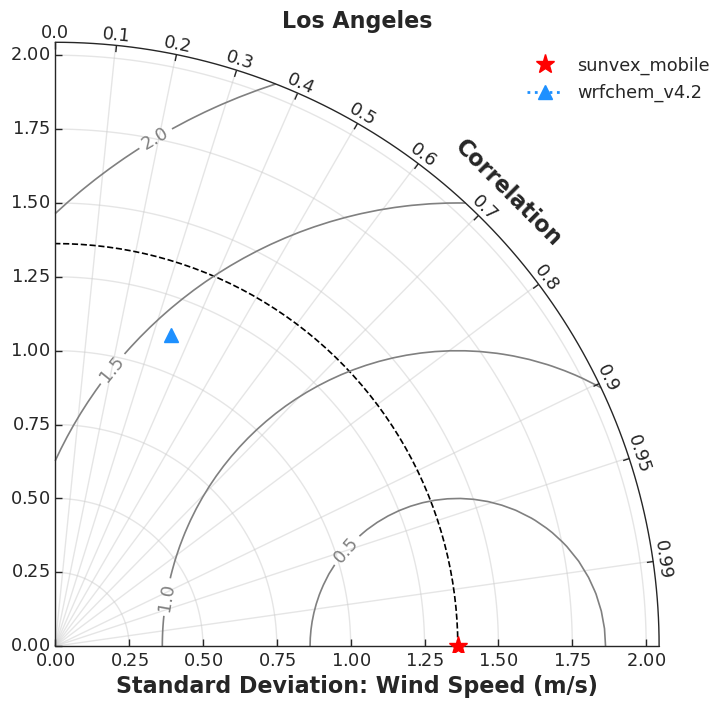

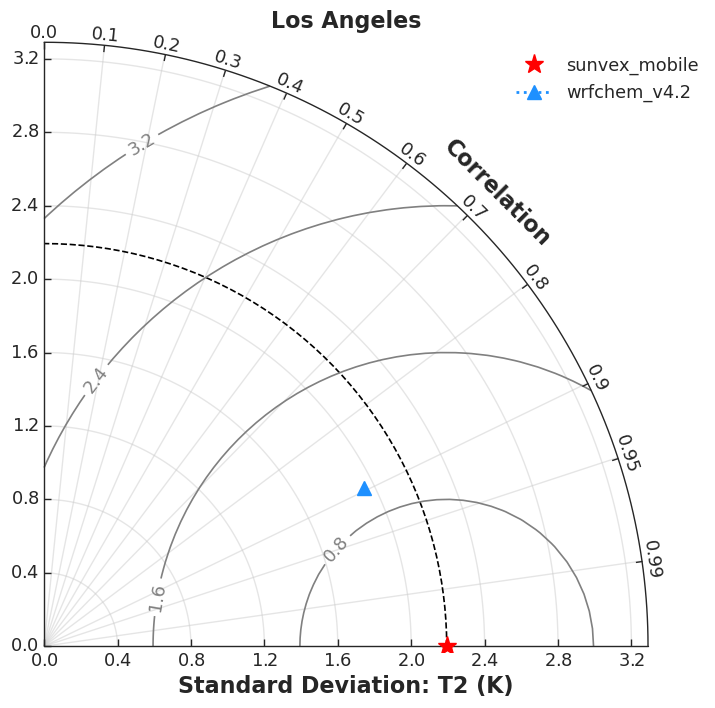

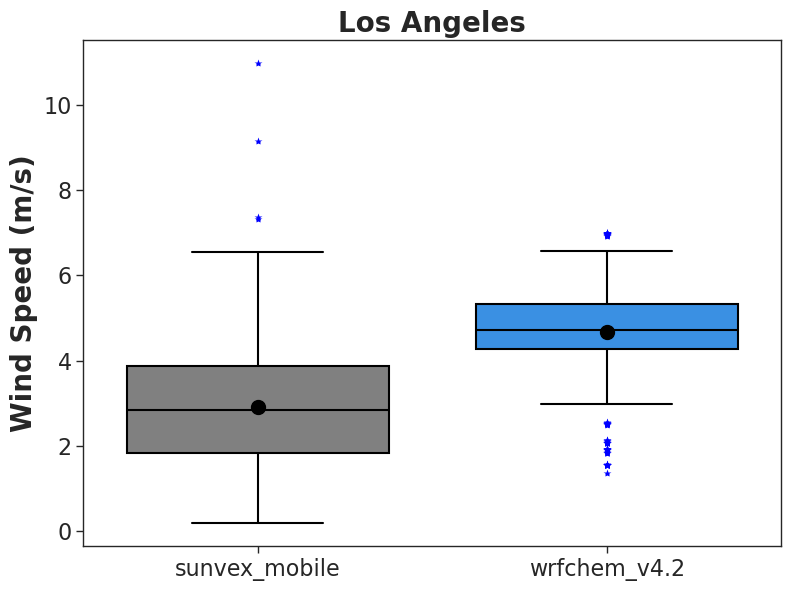

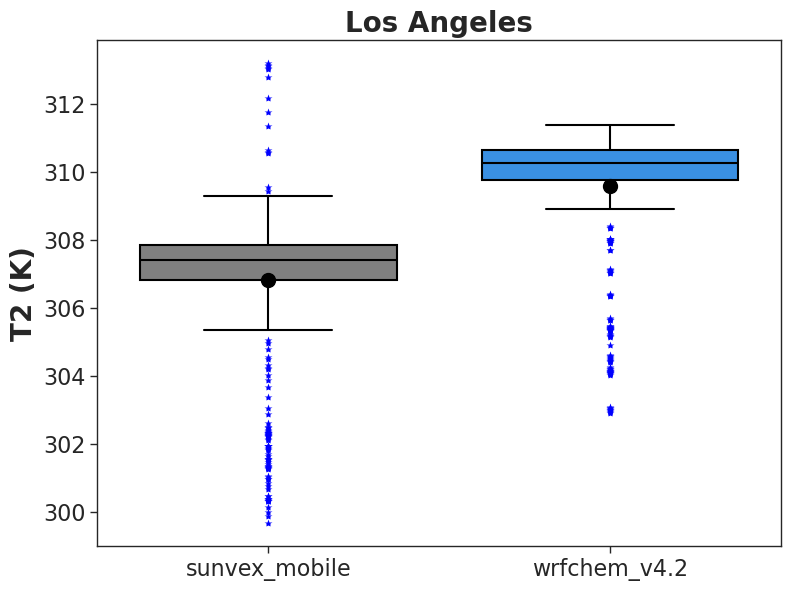

In [15]:
%%time

an.plotting()

In [16]:
%%time

an.stats()

CPU times: user 48.9 ms, sys: 2.92 ms, total: 51.8 ms
Wall time: 55.7 ms
